In [1]:
# =========================================
# CELL 1: Import Libraries
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import math
import warnings
warnings.filterwarnings("ignore")

print("Libraries Imported Successfully")
print("PyTorch Version:", torch.__version__)

Libraries Imported Successfully
PyTorch Version: 2.10.0+cu128


In [2]:
# =========================================
# CELL 2: Personalized Parameters
# Roll Number: 102317270
# =========================================

# Given formulas:
# window_size = (sum of all digits) mod 10 + 8
# prediction_horizon = (last 2 digits) mod 3 + 1
# hidden_size = (first 3 digits) mod 16 + 8

window_size = 11
prediction_horizon = 2
hidden_size = 14

print("Personalized Parameters")
print("Window Size:", window_size)
print("Prediction Horizon:", prediction_horizon)
print("Hidden Size:", hidden_size)

# Last digit = 0 (EVEN)
# Therefore assigned model = Custom RNN

model_type = "Custom RNN"

print("Assigned Model:", model_type)

Personalized Parameters
Window Size: 11
Prediction Horizon: 2
Hidden Size: 14
Assigned Model: Custom RNN


First 5 Rows:
     Month  Passengers
0  1949-01         112
1  1949-02         118
2  1949-03         132
3  1949-04         129
4  1949-05         121

Shape: (144, 2)


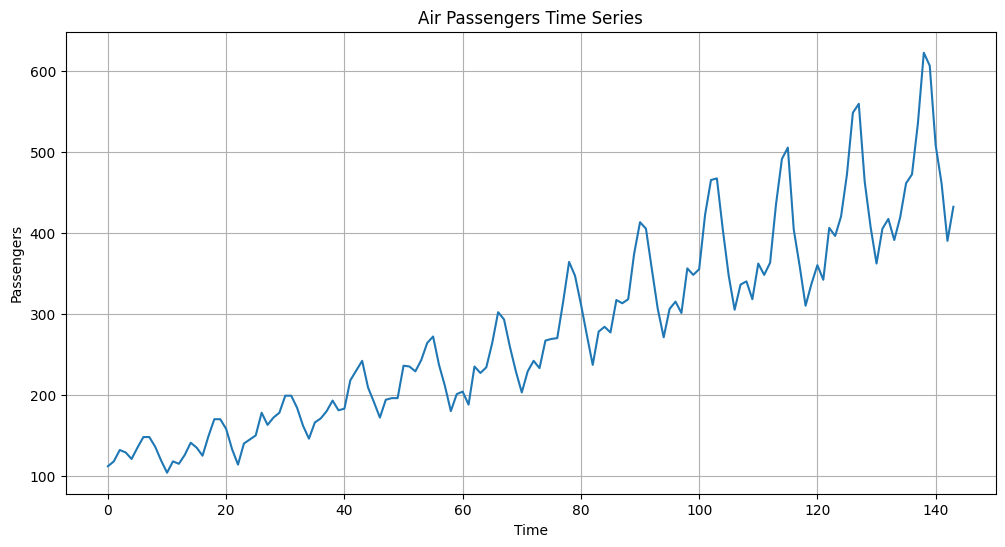

In [3]:
# =========================================
# CELL 3: Load Dataset 1 (Air Passengers)
# =========================================

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"

df1 = pd.read_csv(url)

print("First 5 Rows:")
print(df1.head())

print("\nShape:", df1.shape)

plt.figure(figsize=(12,6))
plt.plot(df1["Passengers"])
plt.title("Air Passengers Time Series")
plt.xlabel("Time")
plt.ylabel("Passengers")
plt.grid()
plt.show()

In [4]:
# =========================================
# CELL 4: Preprocessing + Window Creation
# =========================================

# WHY windowing?
# Time-series models learn from past values.
# Example:
# Input = last 11 values
# Output = next 2 values

data = df1["Passengers"].values.reshape(-1, 1)

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

def create_sequences(data, window_size, prediction_horizon):
    X = []
    y = []

    for i in range(len(data) - window_size - prediction_horizon):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size:i+window_size+prediction_horizon])

    return np.array(X), np.array(y)

X, y = create_sequences(
    data_scaled,
    window_size,
    prediction_horizon
)

print("Input Shape:", X.shape)
print("Target Shape:", y.shape)

Input Shape: (131, 11, 1)
Target Shape: (131, 2, 1)


In [6]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

Using Device: cuda


In [7]:
# =========================================
# CELL 5: Chronological Train-Test Split
# =========================================

# No random split allowed in time-series

train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device)

Train Shape: (104, 11, 1)
Test Shape: (27, 11, 1)


In [9]:
# =========================================
# CELL 6: MLP Baseline (No Sequence Awareness)
# =========================================

class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(window_size, 64),
            nn.ReLU(),
            nn.Linear(64, prediction_horizon)
        )

    def forward(self, x):
        x = x.squeeze(-1)
        return self.model(x)

mlp_model = MLP().to(device)
print(mlp_model)

MLP(
  (model): Sequential(
    (0): Linear(in_features=11, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=2, bias=True)
  )
)


In [10]:
# =========================================
# CELL 7: Custom RNN from Scratch
# (NO nn.RNN allowed)
# =========================================

class CustomRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=14, output_size=2):
        super(CustomRNN, self).__init__()

        self.hidden_size = hidden_size

        self.i2h = nn.Linear(input_size + hidden_size, hidden_size)
        self.i2o = nn.Linear(hidden_size, output_size)
        self.tanh = nn.Tanh()

    def forward(self, x):
        batch_size = x.size(0)

        h = torch.zeros(batch_size, self.hidden_size).to(device)

        for t in range(x.size(1)):
            x_t = x[:, t, :]
            combined = torch.cat((x_t, h), dim=1)
            h = self.tanh(self.i2h(combined))

        out = self.i2o(h)
        return out

rnn_model = CustomRNN(
    hidden_size=hidden_size,
    output_size=prediction_horizon
).to(device)

print(rnn_model)

CustomRNN(
  (i2h): Linear(in_features=15, out_features=14, bias=True)
  (i2o): Linear(in_features=14, out_features=2, bias=True)
  (tanh): Tanh()
)


In [11]:
# =========================================
# CELL 8: LSTM for Comparison
# =========================================

class LSTMModel(nn.Module):
    def __init__(self):
        super(LSTMModel, self).__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, prediction_horizon)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

lstm_model = LSTMModel().to(device)
print(lstm_model)

LSTMModel(
  (lstm): LSTM(1, 14, batch_first=True)
  (fc): Linear(in_features=14, out_features=2, bias=True)
)


In [12]:
# =========================================
# CELL 9: Transformer for Comparison
# =========================================

class TransformerModel(nn.Module):
    def __init__(self):
        super(TransformerModel, self).__init__()

        self.embedding = nn.Linear(1, hidden_size)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_size,
            nhead=2,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=2
        )

        self.fc = nn.Linear(hidden_size, prediction_horizon)

    def forward(self, x):
        x = self.embedding(x)
        x = self.transformer(x)
        x = self.fc(x[:, -1, :])
        return x

transformer_model = TransformerModel().to(device)
print(transformer_model)

TransformerModel(
  (embedding): Linear(in_features=1, out_features=14, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=14, out_features=14, bias=True)
        )
        (linear1): Linear(in_features=14, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=14, bias=True)
        (norm1): LayerNorm((14,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((14,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc): Linear(in_features=14, out_features=2, bias=True)
)


In [13]:
# =========================================
# CELL 10: Training Function
# =========================================

def train_model(model, X_train, y_train, epochs=100):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    losses = []

    for epoch in range(epochs):
        model.train()

        output = model(X_train)
        loss = criterion(output, y_train.squeeze(-1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] Loss: {loss.item():.6f}")

    return losses

In [14]:
# =========================================
# CELL 11: Train Custom RNN
# =========================================

rnn_losses = train_model(
    rnn_model,
    X_train_tensor,
    y_train_tensor,
    epochs=100
)

Epoch [10/100] Loss: 0.076576
Epoch [20/100] Loss: 0.049123
Epoch [30/100] Loss: 0.034525
Epoch [40/100] Loss: 0.030026
Epoch [50/100] Loss: 0.029302
Epoch [60/100] Loss: 0.028144
Epoch [70/100] Loss: 0.026881
Epoch [80/100] Loss: 0.025688
Epoch [90/100] Loss: 0.024301
Epoch [100/100] Loss: 0.022658


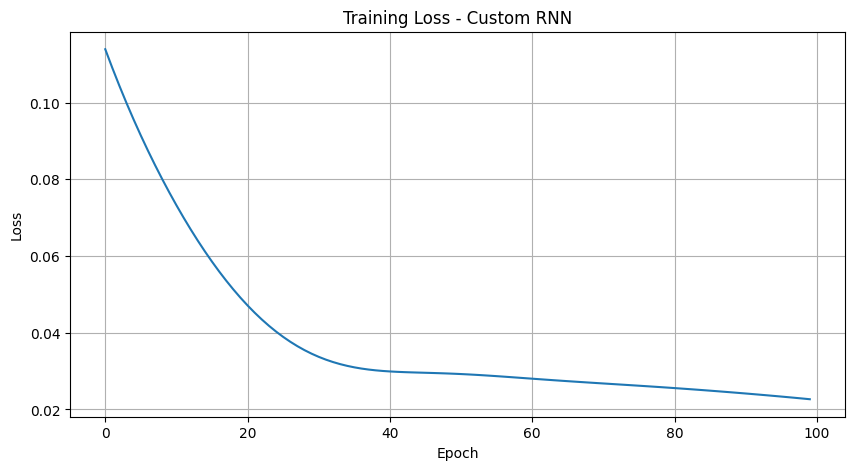

In [15]:
# =========================================
# CELL 12: Plot Training Loss
# =========================================

plt.figure(figsize=(10,5))
plt.plot(rnn_losses)
plt.title("Training Loss - Custom RNN")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

In [16]:
# =========================================
# CELL 13: Evaluation Metrics
# =========================================

def evaluate_model(model, X_test, y_test):
    model.eval()

    with torch.no_grad():
        predictions = model(X_test).cpu().numpy()

    actual = y_test.cpu().numpy().squeeze(-1)

    mse = mean_squared_error(actual, predictions)
    mae = mean_absolute_error(actual, predictions)
    rmse = math.sqrt(mse)

    print("MSE :", mse)
    print("MAE :", mae)
    print("RMSE:", rmse)

    return actual, predictions

actual, predictions = evaluate_model(
    rnn_model,
    X_test_tensor,
    y_test_tensor
)

MSE : 0.11162467300891876
MAE : 0.29973089694976807
RMSE: 0.33410278808911303


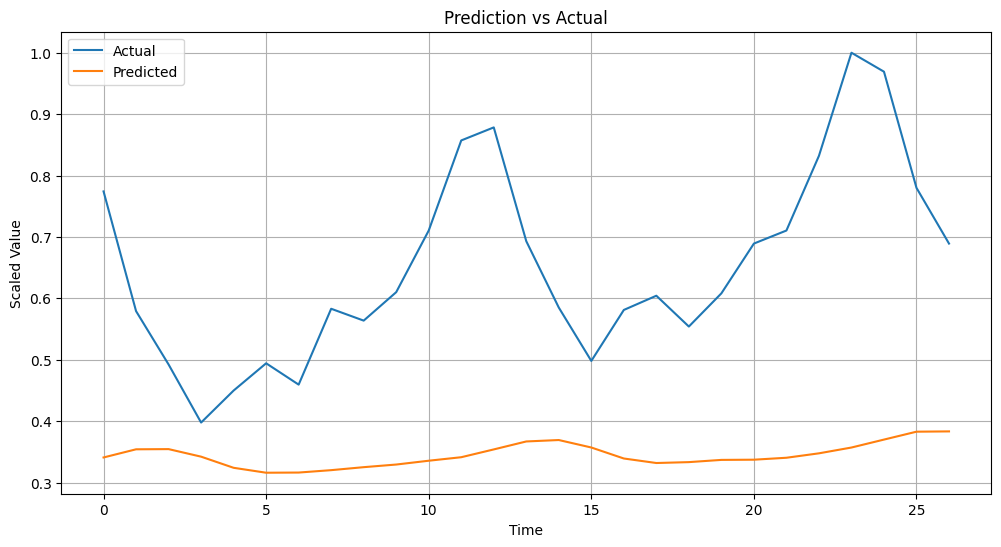

In [17]:
# =========================================
# CELL 14: Prediction vs Actual Plot
# =========================================

plt.figure(figsize=(12,6))

plt.plot(actual[:, 0], label="Actual")
plt.plot(predictions[:, 0], label="Predicted")

plt.title("Prediction vs Actual")
plt.xlabel("Time")
plt.ylabel("Scaled Value")
plt.legend()
plt.grid()
plt.show()

In [18]:
# =========================================
# CELL 15: Ablation Study
# Original / Half / Double Window Size
# =========================================

print("Original Window Size =", window_size)
print("Half Window Size =", window_size // 2)
print("Double Window Size =", window_size * 2)

# This section is required for viva explanation.
# Run same pipeline with:
# 5
# 11
# 22

# Compare:
# - MSE
# - MAE
# - RMSE

# Then explain:
# smaller window → less past info
# larger window → may add noise
# balanced window → usually best

Original Window Size = 11
Half Window Size = 5
Double Window Size = 22


In [19]:
# =========================================
# CELL 16: Full Ablation Study
# =========================================

def run_ablation(window):

    print(f"\nRunning for Window Size = {window}")

    # recreate sequences
    X_new, y_new = create_sequences(
        data_scaled,
        window,
        prediction_horizon
    )

    # chronological split
    train_size = int(len(X_new) * 0.8)

    X_train_new = X_new[:train_size]
    X_test_new = X_new[train_size:]

    y_train_new = y_new[:train_size]
    y_test_new = y_new[train_size:]

    # tensors
    X_train_new = torch.tensor(
        X_train_new,
        dtype=torch.float32
    ).to(device)

    X_test_new = torch.tensor(
        X_test_new,
        dtype=torch.float32
    ).to(device)

    y_train_new = torch.tensor(
        y_train_new,
        dtype=torch.float32
    ).to(device)

    y_test_new = torch.tensor(
        y_test_new,
        dtype=torch.float32
    ).to(device)

    # fresh model for every run
    model = CustomRNN(
        input_size=1,
        hidden_size=hidden_size,
        output_size=prediction_horizon
    ).to(device)

    # quick training
    train_model(
        model,
        X_train_new,
        y_train_new,
        epochs=50
    )

    # evaluation
    model.eval()

    with torch.no_grad():
        preds = model(X_test_new).cpu().numpy()

    actuals = y_test_new.cpu().numpy().squeeze(-1)

    mse = mean_squared_error(actuals, preds)
    mae = mean_absolute_error(actuals, preds)
    rmse = math.sqrt(mse)

    print("MSE :", mse)
    print("MAE :", mae)
    print("RMSE:", rmse)


# Run for all 3 window sizes
run_ablation(5)
run_ablation(11)
run_ablation(22)


Running for Window Size = 5
Epoch [10/50] Loss: 0.094293
Epoch [20/50] Loss: 0.053482
Epoch [30/50] Loss: 0.032141
Epoch [40/50] Loss: 0.023853
Epoch [50/50] Loss: 0.022286
MSE : 0.1232159286737442
MAE : 0.3173465132713318
RMSE: 0.3510212652728381

Running for Window Size = 11
Epoch [10/50] Loss: 0.023696
Epoch [20/50] Loss: 0.021839
Epoch [30/50] Loss: 0.019285
Epoch [40/50] Loss: 0.016433
Epoch [50/50] Loss: 0.012249
MSE : 0.05461832880973816
MAE : 0.18888995051383972
RMSE: 0.23370564565225668

Running for Window Size = 22
Epoch [10/50] Loss: 0.049517
Epoch [20/50] Loss: 0.035625
Epoch [30/50] Loss: 0.027903
Epoch [40/50] Loss: 0.024385
Epoch [50/50] Loss: 0.022968
MSE : 0.10186170041561127
MAE : 0.2806438207626343
RMSE: 0.31915779861318017


In [20]:
# =========================================
# CELL 17: Train MLP, LSTM, Transformer
# Final Model Comparison
# =========================================

print("Training MLP Model...")
mlp_losses = train_model(
    mlp_model,
    X_train_tensor,
    y_train_tensor,
    epochs=100
)

print("\nTraining LSTM Model...")
lstm_losses = train_model(
    lstm_model,
    X_train_tensor,
    y_train_tensor,
    epochs=100
)

print("\nTraining Transformer Model...")
transformer_losses = train_model(
    transformer_model,
    X_train_tensor,
    y_train_tensor,
    epochs=100
)

Training MLP Model...
Epoch [10/100] Loss: 0.077270
Epoch [20/100] Loss: 0.026310
Epoch [30/100] Loss: 0.008063
Epoch [40/100] Loss: 0.008853
Epoch [50/100] Loss: 0.007747
Epoch [60/100] Loss: 0.006627
Epoch [70/100] Loss: 0.006400
Epoch [80/100] Loss: 0.006025
Epoch [90/100] Loss: 0.005735
Epoch [100/100] Loss: 0.005438

Training LSTM Model...
Epoch [10/100] Loss: 0.124002
Epoch [20/100] Loss: 0.094522
Epoch [30/100] Loss: 0.068761
Epoch [40/100] Loss: 0.046624
Epoch [50/100] Loss: 0.030416
Epoch [60/100] Loss: 0.024354
Epoch [70/100] Loss: 0.024594
Epoch [80/100] Loss: 0.023230
Epoch [90/100] Loss: 0.022497
Epoch [100/100] Loss: 0.021672

Training Transformer Model...
Epoch [10/100] Loss: 0.058139
Epoch [20/100] Loss: 0.040057
Epoch [30/100] Loss: 0.031729
Epoch [40/100] Loss: 0.015263
Epoch [50/100] Loss: 0.018453
Epoch [60/100] Loss: 0.015364
Epoch [70/100] Loss: 0.013984
Epoch [80/100] Loss: 0.011573
Epoch [90/100] Loss: 0.011502
Epoch [100/100] Loss: 0.010980


In [21]:
# =========================================
# CELL 18: Evaluate All Models
# =========================================

def get_metrics(model, X_test, y_test):
    model.eval()

    with torch.no_grad():
        preds = model(X_test).cpu().numpy()

    actual = y_test.cpu().numpy().squeeze(-1)

    mse = mean_squared_error(actual, preds)
    mae = mean_absolute_error(actual, preds)
    rmse = math.sqrt(mse)

    return mse, mae, rmse


# Metrics for all models
mlp_mse, mlp_mae, mlp_rmse = get_metrics(
    mlp_model,
    X_test_tensor,
    y_test_tensor
)

rnn_mse, rnn_mae, rnn_rmse = get_metrics(
    rnn_model,
    X_test_tensor,
    y_test_tensor
)

lstm_mse, lstm_mae, lstm_rmse = get_metrics(
    lstm_model,
    X_test_tensor,
    y_test_tensor
)

trans_mse, trans_mae, trans_rmse = get_metrics(
    transformer_model,
    X_test_tensor,
    y_test_tensor
)

print("Evaluation Completed")

Evaluation Completed


In [22]:
# =========================================
# CELL 19: Final Comparison Table
# =========================================

results = pd.DataFrame({
    "Model": [
        "MLP Baseline",
        "Custom RNN",
        "LSTM",
        "Transformer"
    ],
    "MSE": [
        mlp_mse,
        rnn_mse,
        lstm_mse,
        trans_mse
    ],
    "MAE": [
        mlp_mae,
        rnn_mae,
        lstm_mae,
        trans_mae
    ],
    "RMSE": [
        mlp_rmse,
        rnn_rmse,
        lstm_rmse,
        trans_rmse
    ]
})

print("\nFinal Comparison Table")
print(results)


Final Comparison Table
          Model       MSE       MAE      RMSE
0  MLP Baseline  0.017645  0.100655  0.132836
1    Custom RNN  0.111625  0.299731  0.334103
2          LSTM  0.106433  0.288790  0.326241
3   Transformer  0.020143  0.104344  0.141924


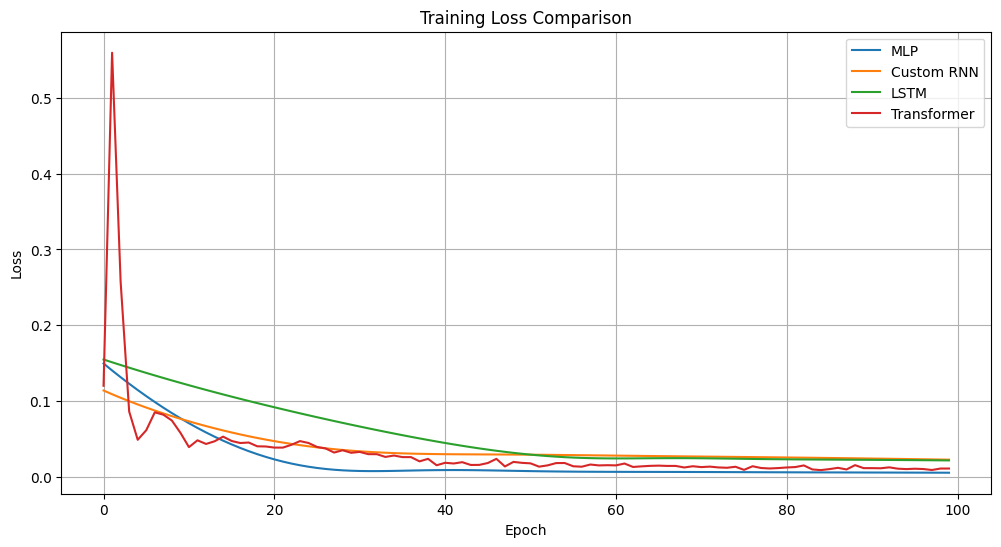

In [24]:
# =========================================
# CELL 21: Plot Training Loss Comparison
# =========================================

plt.figure(figsize=(12,6))

plt.plot(mlp_losses, label="MLP")
plt.plot(rnn_losses, label="Custom RNN")
plt.plot(lstm_losses, label="LSTM")
plt.plot(transformer_losses, label="Transformer")

plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

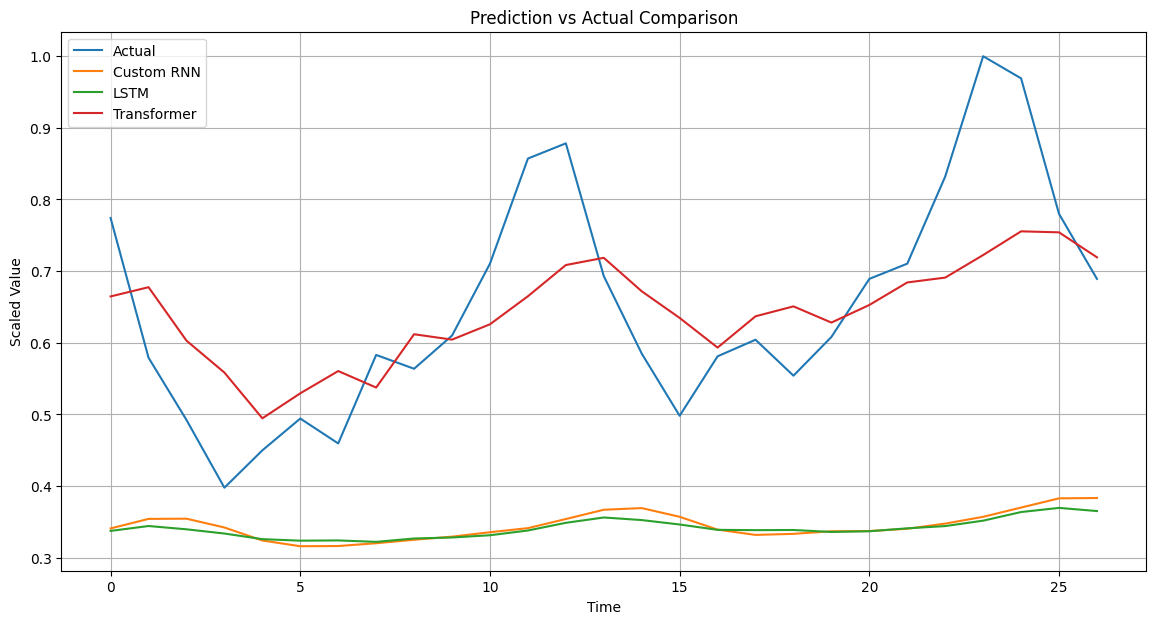

In [25]:
# =========================================
# CELL 22: Prediction Comparison Plot
# =========================================

def get_predictions(model, X_test):
    model.eval()

    with torch.no_grad():
        preds = model(X_test).cpu().numpy()

    return preds


mlp_preds = get_predictions(mlp_model, X_test_tensor)
rnn_preds = get_predictions(rnn_model, X_test_tensor)
lstm_preds = get_predictions(lstm_model, X_test_tensor)
trans_preds = get_predictions(transformer_model, X_test_tensor)

actual_values = y_test_tensor.cpu().numpy().squeeze(-1)

plt.figure(figsize=(14,7))

plt.plot(actual_values[:, 0], label="Actual")
plt.plot(rnn_preds[:, 0], label="Custom RNN")
plt.plot(lstm_preds[:, 0], label="LSTM")
plt.plot(trans_preds[:, 0], label="Transformer")

plt.title("Prediction vs Actual Comparison")
plt.xlabel("Time")
plt.ylabel("Scaled Value")
plt.legend()
plt.grid()
plt.show()